<a href="https://colab.research.google.com/github/HieuStudyingCS/Learning-AI-Journey/blob/main/Gradient_Descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gradient Descent
Trong bài này thì chủ đề sẽ là Gradient Descent, đi từ nhiều góc nhìn và các biến thể khác của Gradient Descent

In [ ]:
from IPython.display import display, Image

Trước khi tìm hiểu về Gradient Descent, ta làm rõ một số khái niệm sau:
Xét một hàm số $$f: \mathcal{R}^d \to \mathcal{R}$$

- Điểm $f(\mathbf{x^*})$ được gọi là *cực tiểu toàn cục* (tương ứng với *cực đại toàn cục*) nếu $f(\mathbf{x}) \geq f(\mathbf{x^*})$ (tương ứng với $f(\mathbf{x}) \leq f(\mathbf{x^*})$) với mọi $\mathbf{x}$ thuộc tập xác định $\mathcal{D}$. Các
điểm cực tiểu toàn cục và cực đại toàn cục được gọi chung là *cực trị toàn cục*.

- Điểm $\mathbf{x^*}$ được gọi là *cực tiểu địa phương* (tương ứng với *cực đại địa phương*) nếu tồn tại $\epsilon > 0$ sao cho $f(\mathbf{x}) \geq f(\mathbf{x^*})$ (tương ứng với $f(\mathbf{x}) \leq f(\mathbf{x^*})$)với mọi $\mathbf{x}$ thuộc vào tập lân cận $\mathcal{V}(\epsilon) = \{\mathbf{x}: \mathbf{x} \in \mathcal{D}, d(\mathbf{x}, \mathbf{x^*}) \leq \epsilon\}$. Ký hiệu $d(\mathbf{x}, \mathbf{x^*})$ là khoảng cách giữa 2 vector $\mathbf{x}$ và $\mathbf{x^*}$, thường là khoảng cách Euclidean.

- Các điểm cực tiểu địa phương và cực đại địa phương được gọi chung là cực trị địa phương. Các điểm cực tiểu/cực đại/cực trị toàn cục cũng là các điểm cực tiểu/cực đại/cực trị địa phương.

# 1. Introduction to Gradient Descent

Gradient Descent (GD) là một kỹ thuật tìm kiếm điểm tối ưu cho loss function trong Machine Learning (có thể là local hoặc global minimum tùy tính chất của bài toán)

## 1.1. Gradient Descent cho hàm 1 biến

Dễ thấy:

1. Nếu đạo hàm của hàm số tại $x_t$: $f'(x_t) > 0$ thì $x_t$ nằm về bên phải so với $x^{*}$ (và ngược lại). Để điểm tiếp theo $x_{t+1}$ gần với $x^{*}$  hơn, chúng ta cần di chuyển $x_t$ về phía bên trái, tức về phía *âm*. Nói cách khác, **chúng ta cần di chuyển ngược dấu với đạo hàm**: $x_{t+1}=x_t+ Δ$. Trong đó Δ là một đại lượng ngược dấu với đạo hàm $f'(x_t)$.
    
Điều này dễ hiểu vì theo tính chất của tính đơn điệu của hàm số, ta có:

$$
f’(x_t) > 0 = f{(x^{*})} \Rightarrow x_t > x^{*}
$$

Nói cách khác, khi hàm số đồng biến, thì điểm $x$ tại thời điểm $t$ (hay $x_t$) sẽ nằm về bên phải của optimal point $x^{*}$.

Điều ngược lại xảy ra tương tự với hàm nghịch biến.

    
2. Khi $x_t$ càng xa $x^{*}$ về phía bên phải thì $f’(x_t)$ càng lớn hơn 0 (và ngược lại). Vậy, lượng di chuyển Δ, một cách trực quan nhất, là tỉ lệ thuận với $-f’(x_t)$.
3. Kết luận:

$$
x_{t+1} = x_t - \eta f'(x_t) \tag{1.1.1}
$$

Trong đó, $\eta$ được gọi là learning rate. Dấu trừ thể hiện việc chúng ta phải *đi ngược* với đạo hàm (Đây cũng chính là lý do phương pháp này được gọi là Gradient Descent - *descent* nghĩa là *đi ngược*). Các quan sát đơn giản phía trên, mặc dù không phải đúng cho tất cả các bài toán, là nền tảng cho rất nhiều phương pháp tối ưu nói chung và thuật toán Machine Learning nói riêng.

Tốc độ hội tụ của GD không những phụ thuộc vào điểm khởi tạo ban đầu mà còn phụ thuộc vào *learning rate*.

1. Với learning rate nhỏ, tốc độ hội tụ chậm hơn và tốn chi phí tính toán cũng như có thể ko bao giờ tới được optimal point
2. Ngược lại, với learning rate quá lớn thì tốc độ hội tụ là rất nhanh nhưng thuật toán ko thể hội tụ vì bước nhảy quá lớn và khiến nó bị quanh quẩn ở đích nhưng ko chạm được vào đích.

### Làm sao để chọn learning rate phù hợp?

Ví dụ: Giả sử hàm số cần cực tiểu hóa có dạng $f(x) = 3x^{2} + 4x-2$, đi tìm learning rate phù hợp cho bài toán này nếu sử dụng Gradient Descent?

- Rất dễ nhận thấy nghiệm cần tìm (hay optimal point) là $x = -\frac{2}{3}$ nếu sử dụng phương pháp đạo hàm truyền thống, vậy nếu sử dụng Gradient Descent, ta cần chọn learning rate là bao nhiêu để thuật toán hội tụ về đúng điểm $x = -\frac{2}{3}$?
- Nhận thấy, giá trị $x$ tại thời điểm $t+1$ được cập nhật như sau:
    
    $$
    x_{t+1} = x_t - \eta f'(x_t)
    $$
    
- Biến đổi:

$$
x_{t+1} = x_t - \eta f'(x_t) \\
= x_t - \eta(6x_t + 4) \\
= (1 - 6\eta)x_t - 4\eta \\
= (1 - 6\eta)[(1 - 6\eta)x_{t-1} - 4\eta] - 4\eta \\
= (1 - 6\eta)^2 x_{t-1} - (1 - 6\eta)4\eta - 4\eta \\
= (1 - 6\eta)^2 x_{t-1} - [(1 - 6\eta)4\eta + 4\eta] \\
= (1 - 6\eta)^3 x_{t-2} - [(1 - 6\eta)^2 + (1 - 6\eta) + 1]4\eta \\
\quad \dots \dots \dots \\
= (1 - 6\eta)^t x_1 - \left[ \color{red}{(1 - 6\eta)^{t-1} + (1 - 6\eta)^{t-2} + \dots + (1 - 6\eta) + 1} \right] 4\eta \\
= (1 - 6\eta)^t x_1 - \frac{\color{red}{1 - (1 - 6\eta)^t}}{\color{red}{1 - (1 - 6\eta)}} 4\eta = (1 - 6\eta)^t x_1 - \frac{1 - (1 - 6\eta)^t}{6\eta} 4\eta \\
= (1 - 6\eta)^t x_1 + \frac{(1 - 6\eta)^t 4\eta}{6\eta} - \frac{4\eta}{6\eta} = (1 - 6\eta)^t \left[ x_1 + \frac{2}{3} \right] - \frac{2}{3}
$$

Đặt $r = 1 - 6\alpha$, Ta có:
$S = r^{t-1} + r^{t-2} + \dots + r^1 + 1$
$rS = r^t + r^{t-1} + \dots + r^2 + r^1$
$S - rS = 1 - r^t$
$S = \frac{1 - r^t}{1 - r} = {\frac{1 - (1 - 6\alpha)^t}{1 - (1 - 6\alpha)}}$

Nếu $|1-6\eta| < 1$ thì khi $t \to \infty$, ta có $(1-6\eta)^{t} \to 0$. Cuối cùng:  $x_t \to -\frac{2}{3}$

Vậy điều kiện để thuật toán hội tụ tại $x = -\frac{2}{3}$ là $\eta < \frac{1}{3}$

## 1.2. Gradient Descent cho hàm nhiều biến

Giả sử ta cần tìm **global minimum** cho hàm $f(θ)$ trong đó $θ$ (*theta*) là một vector, thường được dùng để ký hiệu tập hợp các tham số của một mô hình cần tối ưu (trong Linear Regression thì các tham số chính là hệ số $w$). Đạo hàm của hàm số đó tại một điểm $θ$ bất kỳ được ký hiệu là $∇θf(θ)$ (hình tam giác ngược đọc là $nabla$). Tương tự như hàm 1 biến, thuật toán GD cho hàm nhiều biến cũng bắt đầu bằng một điểm dự đoán $θ_0$, sau đó, ở vòng lặp thứ $t$, quy tắc cập nhật là:

$$
θ_{t+1}=θ_t−η∇_{θ}f(θ_t)
$$

Hoặc viết dưới dạng đơn giản hơn:

$$
θ=θ−η∇_{θ}f(θ)
$$

Quy tắc cần nhớ: **luôn luôn đi ngược hướng với đạo hàm**.

## 1.2.1. Kiểm tra đạo hàm

### a. Lý thuyết

Việc tính đạo hàm của hàm nhiều biến thông thường khá phức tạp và rất dễ mắc lỗi, nếu chúng ta tính sai đạo hàm thì thuật toán GD không thể chạy đúng được. Trong thực nghiệm, có một cách để kiểm tra liệu đạo hàm tính được có chính xác không. Cách này dựa trên định nghĩa của đạo hàm (cho hàm 1 biến):

$$
f'(x) = \lim_{\varepsilon \to 0}{\frac{f(x + \varepsilon) - f(x)}{\varepsilon}}
$$

Một cách thường dùng là lấy giá trị $\varepsilon$ rất nhỏ , ví dụ $10^{-6}$ , và dùng công thức:

$$
f'(x) \approx \frac{f(x+\varepsilon) - f(x-\varepsilon)}{2\varepsilon} \tag{2}
$$

Cách tính này được gọi là *numerical gradient*.

### b. Chứng minh tính hiệu quả công thức numerical gradient

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


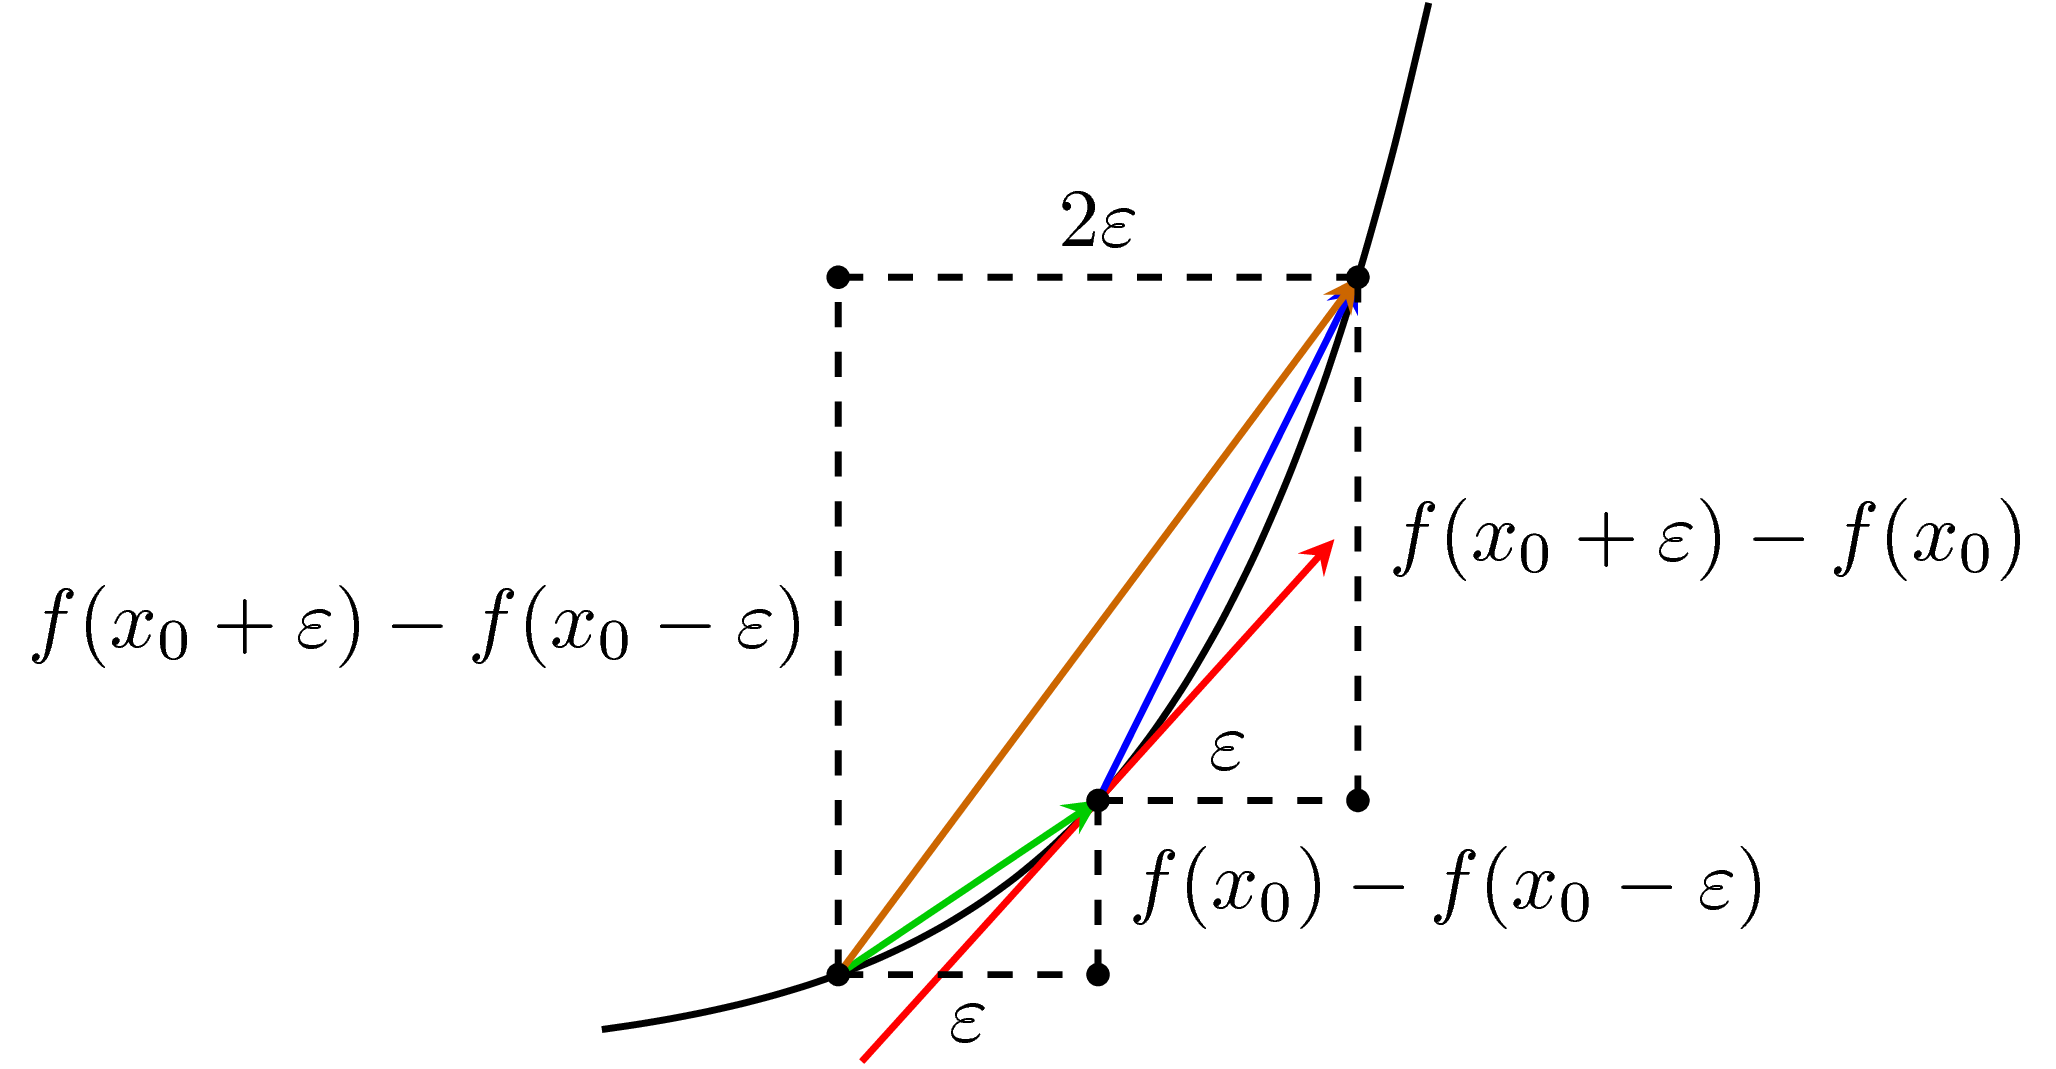

In [ ]:
file_path_pic_1 = '/content/drive/MyDrive/Hình project google colab/Gradient_Descent/1.png'
display(Image(filename=file_path_pic_1, width=600))

#### Chứng minh qua hình học

Trong hình, vector màu đỏ là đạo hàm *chính xác* của hàm số tại điểm có hoành độ bằng $x_0$. Vector màu xanh lam thể hiện cách xấp xỉ đạo hàm phía phải. Vector màu xanh lục thể hiện cách xấp xỉ đạo hàm phía trái. Vector màu nâu thể hiện cách xấp xỉ đạo hàm hai phía. Trong ba vector xấp xỉ đó, vector xấp xỉ hai phía màu nâu là gần với vector đỏ nhất nếu xét theo hướng.

Sự khác biệt giữa các cách xấp xỉ còn lớn hơn nữa nếu tại điểm $x$, hàm số bị *bẻ cong* mạnh hơn. Khi đó, xấp xỉ trái và phải sẽ khác nhau rất nhiều. Xấp xỉ hai bên sẽ *ổn định* hơn.

#### Chứng minh qua Giải tích

Ý tưởng: Sử dụng ***Khai triển Taylor***

Với $\varepsilon$ rất nhỏ, ta có hai xấp xỉ sau đây:

$$
f(x + \varepsilon) \approx f(x) + f'(x)\varepsilon + \frac{f''(x)}{2}\varepsilon^{2} + \dots
$$

Và:

$$
f(x- \varepsilon) \approx f(x) - f'(x)\varepsilon + \frac{f''(x)}{2}\varepsilon^{2} - \dots
$$

Từ đây, ta có:

$$
\frac{f(x + \varepsilon) - f(x)}{\varepsilon} \approx f'(x) + \frac{f''(x)}{2}\varepsilon + \dots = f'(x) + O(\varepsilon) \tag{3}
$$

$$
\frac{f(x + \varepsilon) - f(x - \varepsilon)}{2\varepsilon} \approx f'(x) + \frac{f^{(3)}(x)}{6}\varepsilon^{2} + \dots = f'(x) + O(\varepsilon^{2}) \tag{4}
$$

Từ đó, nếu xấp xỉ đạo hàm bằng công thức (3) (xấp xỉ đạo hàm phải), sai số sẽ là $O(\varepsilon)$. Trong khi đó, nếu xấp xỉ đạo hàm bằng công thức (4) (xấp xỉ đạo hàm hai phía), sai số là $O(\varepsilon^{2}) << O(\varepsilon)$ nếu $\varepsilon$ nhỏ.  

#### Kết luận

Cả hai cách giải thích trên đây đều cho chúng ta thấy rằng, xấp xỉ đạo hàm hai phía là xấp xỉ tốt hơn.

### c. Code

```python
def grad(w):
    N = Xbar.shape[0]
    return 1/N * Xbar.T.dot(Xbar.dot(w) - y)

def cost(w):
    N = Xbar.shape[0]
    return .5/N*np.linalg.norm(y - Xbar.dot(w), 2)**2
    
def numerical_grad(w, cost):
    eps = 1e-4
    g = np.zeros_like(w)
    for i in range(len(w)):
        w_p = w.copy()
        w_n = w.copy()
        w_p[i] += eps
        w_n[i] -= eps
        g[i] = (cost(w_p) - cost(w_n))/(2*eps)
    return g

def check_grad(w, cost, grad):
    w = np.random.rand(w.shape[0], w.shape[1])
    grad1 = grad(w)
    grad2 = numerical_grad(w, cost)
    return True if np.linalg.norm(grad1 - grad2) < 1e-6 else False

print( 'Checking gradient...', check_grad(np.random.rand(2, 1), cost, grad))
```

(Nếu muốn kiểm tra đạo hàm trên các hàm khác, ta chỉ cần thay đổi các hàm `grad` và `cost` rồi áp dụng hàm `numerical_grad` và `check_grad` như trên là được)

Ngoài ra thì còn có một vài đoạn code tôi mở rộng thêm dưới đây  
[Matrix Calculus - Gradient](https://colab.research.google.com/drive/1oVqyDJPpy16FV5KWOsYk4086pbaou8oX)


Code cho Gradient Descent (có bao gồm các biến thể tăng tốc Gradient Descent và Stochastic GD, Mini-batch GD)  
[GD - Nesterov's AGD - MGD](https://colab.research.google.com/drive/1fjcsotsltwlHeoMnvEqI3quqBJX9FTQN)  
[SGD](https://colab.research.google.com/drive/13lvfmIbVHtMxuk5mVZ40S-r4zee0gXwa)

### Notes for GD

- Nghiệm cuối cùng của Gradient Descent phụ thuộc rất nhiều vào điểm khởi tạo và learning rate.

# 2. Các thuật toán tối ưu Gradient Descent

- Các hạn chế của GD đã được đề cập ở trên, nên trong mục này sẽ bàn về những kỹ thuật tối ưu GD - khắc phục hạn chế của thuật này cùng với các thuật toán tối ưu hóa khác (biến thể của GD) được dùng trong DL Models

## 2.1. Momentum-based GD

Nhắc lại về GD:

Giả sử ta có $\mathcal{L}(\mathbf{w})$ là loss function mà ta cần tối ưu. Mong muốn của chúng ta khi ứng dụng Gradient Descent đó là tìm điểm tối ưu (optimal point) $x^{*}$ toàn cục (có thể là local khi các hàm có độ dốc quá lớn và có nhiều local minimum khiến cho thuật toán khó hội tụ về global minimum).  Thuật toán GD được mô tả qua 2 bước:

1. Dự đoán điểm khởi tạo $\theta = \theta_0$.
2. Cập nhật  $\theta$ cho đến khi thuật toán hội tụ

$$
\mathbf{\theta} = \mathbf{\theta} - \eta\nabla_{\mathbf{\theta}}\mathcal{L}(\mathbf{w})
$$

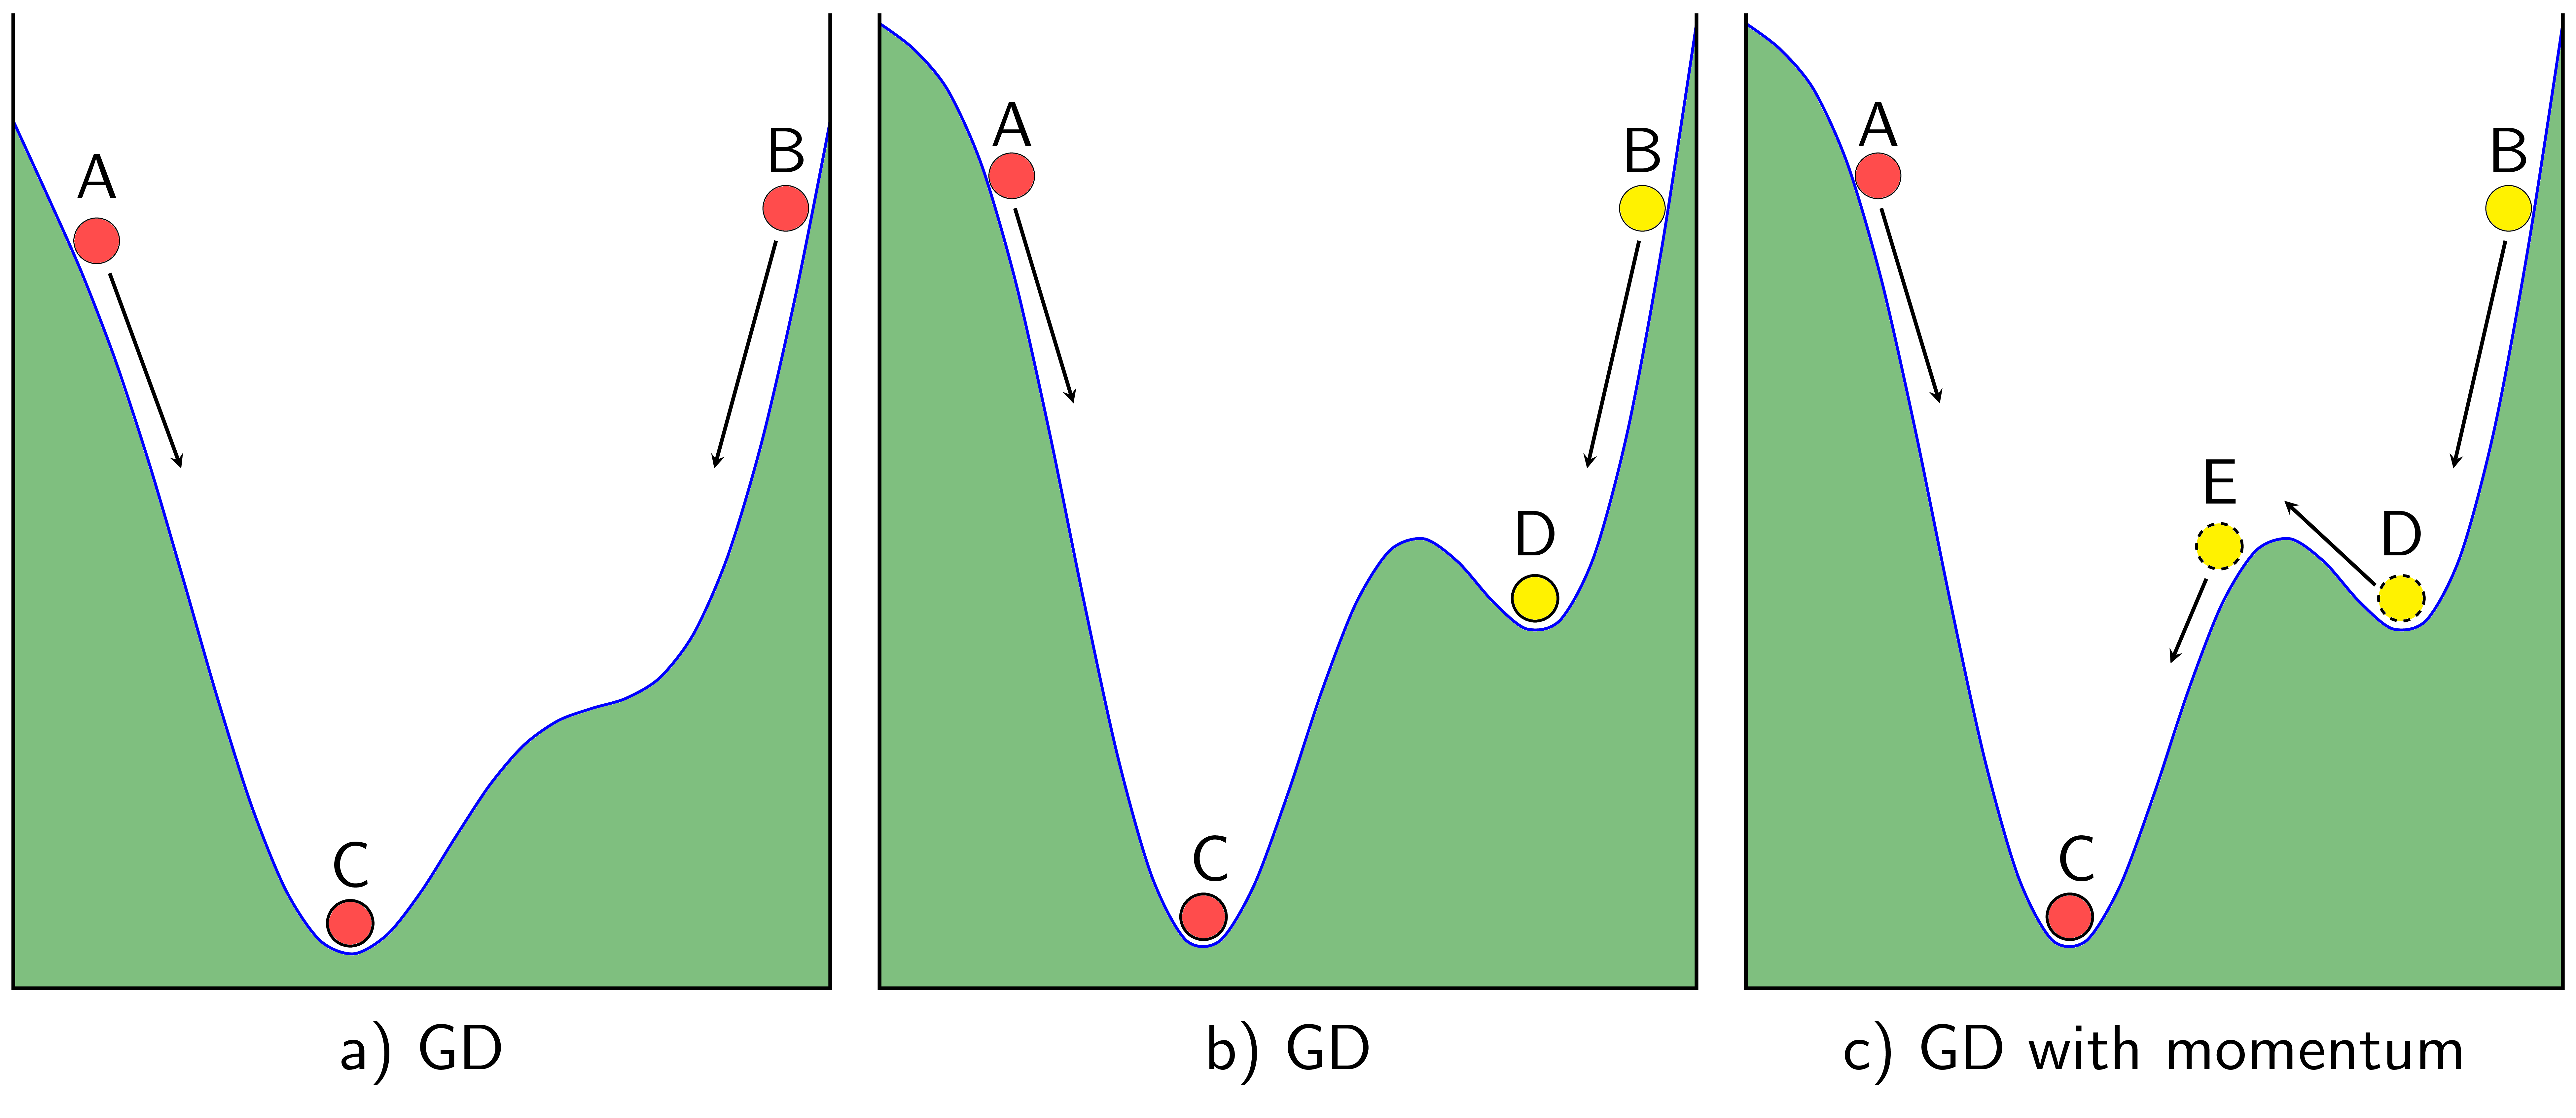

In [ ]:
file_path_pic_2 = '/content/drive/MyDrive/Hình project google colab/Gradient_Descent/2.png'
display(Image(filename=file_path_pic_2, width=600))

Nếu như bề mặt có hai đáy thung lũng như Hình 1b) thì tùy vào việc đặt bi ở A hay B, vị trí cuối cùng của bi sẽ ở C hoặc D. Điểm D là một điểm local minimum chúng ta không mong muốn.

Nếu suy nghĩ một cách vật lý hơn, vẫn trong Hình 1b), nếu vận tốc ban đầu của bi khi ở điểm B đủ lớn, khi bi lăn đến điểm D, theo *đà*, bi có thể tiếp tục di chuyển lên dốc phía bên trái của D. Và nếu giả sử vận tốc ban đầu lớn hơn nữa, bi có thể vượt dốc tới điểm E rồi lăn xuống C như trong Hình 1c). Đây chính là điều chúng ta mong muốn. Bạn đọc có thể đặt câu hỏi rằng liệu bi lăn từ A tới C có theo *đà* lăn tới E rồi tới D không. Xin trả lời rằng điều này khó xảy ra hơn vì nếu so với dốc DE thì dốc CE cao hơn nhiều.

Dựa trên hiện tượng này, một thuật toán được ra đời nhằm khắc phục việc nghiệm của GD rơi vào một điểm local minimum không mong muốn. Thuật toán đó có tên là **Momentum**

Trong GD, chúng ta cần tính lượng thay đổi ở thời điểm t để cập nhật vị trí mới cho nghiệm. Nếu chúng ta coi đại lượng này như vận tốc $v_t$ trong vật lý, vị trí mới của *hòn bi* sẽ là $θ_{t+1}=θ_t−v_t$. Dấu trừ thể hiện việc phải di chuyển ngược với đạo hàm. Công việc của chúng ta bây giờ là tính đại lượng $v_t$ sao cho nó vừa mang thông tin của *độ dốc* (tức đạo hàm), vừa mang thông tin của *đà*, tức vận tốc trước đó $v_{t−1}$ (chúng ta coi như vận tốc ban đầu $v_0=0$). Một cách đơn giản nhất, ta có thể cộng (có trọng số) hai đại lượng này lại:

$$
v_t = \gamma v_{t-1} + \eta\nabla_{\theta}J(\theta)
$$

Trong đó $\gamma$ thường được chọn là một giá trị khoảng 0.9, $v_t$ là vận tốc tại thời điểm trước đó, $\nabla_{\theta}J(\theta)$ chính là độ dốc của điểm trước đó. Sau đó vị trí mới của hòn *bi* được xác định như sau:

$$
\theta = \theta - v_t
$$

Thuật toán đơn giản này tỏ ra rất hiệu quả trong các bài toán thực tế (trong không gian nhiều chiều, cách tính toán cũng hoàn toàn tương tự).

Đã có code cho thuật toán này

## 2.2. Nesterov Accelerated Gradient (NAG)

Momentum giúp *hòn bi* vượt qua được *dốc locaminimum*, tuy nhiên, có một hạn chế chúng ta có thể thấy trong ví dụ trên: Khi tới gần *đích*, momemtum vẫn mất khá nhiều thời gian trước khi dừng lại. Lý do lại cũng chính là vì có *đà*. Có một phương pháp khác tiếp tục giúp khắc phục điều này, phương pháp đó mang tên Nesterov accelerated gradient (NAG), giúp cho thuật toán hội tụ nhanh hơn

Ý tưởng cơ bản là *dự đoán hướng đi trong tương lai*, tức nhìn trước một bước! Cụ thể, nếu sử dụng số hạng *momentum*  $\gamma v_{t-1}$ để cập nhật thì ta có thể *xấp xỉ* được vị trí tiếp theo của hòn bi là $\theta - \gamma v_{t-1}$ (chúng ta không đính kèm phần gradient ở đây vì sẽ sử dụng nó trong bước cuối cùng). Vậy, thay vì sử dụng gradient của điểm hiện tại, NAG *đi trước một bước*, sử dụng gradient của điểm tiếp theo. Theo dõi hình dưới đây:

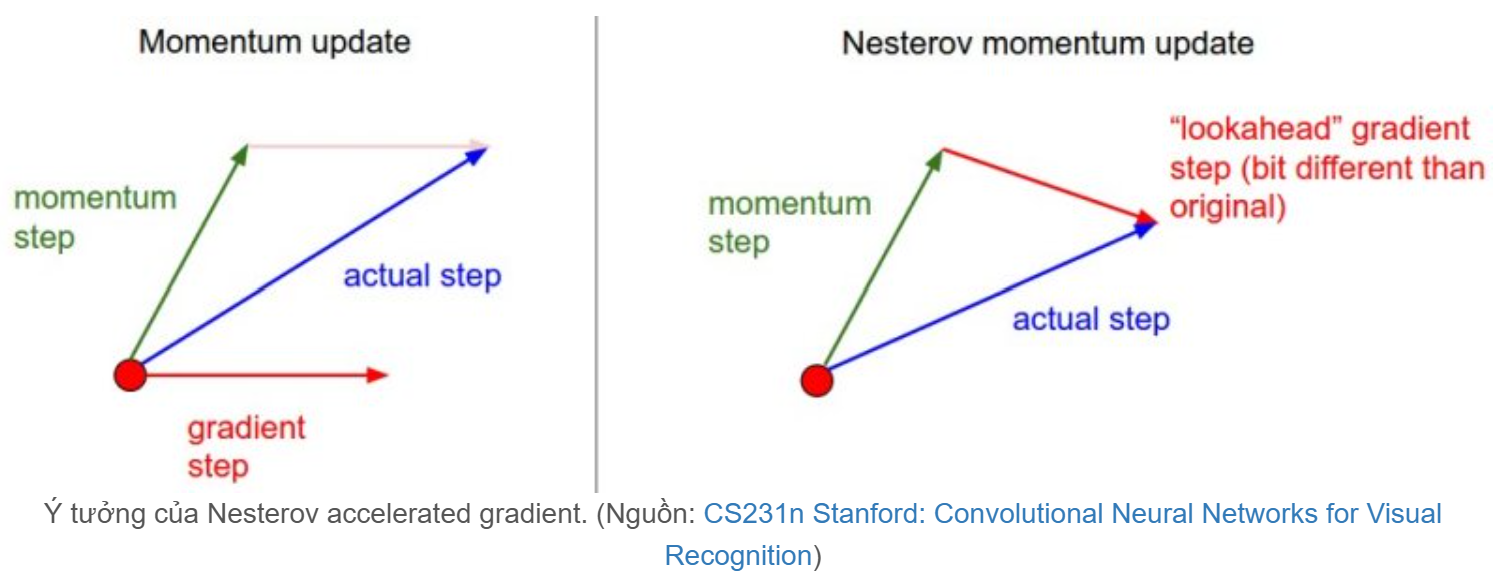

In [ ]:
file_path_pic_3 = '/content/drive/MyDrive/Hình project google colab/Gradient_Descent/3.png'
display(Image(filename=file_path_pic_3, width=600))

- Với momentum thông thường: *lượng thay đổi* là tổng của hai vector: momentum vector và gradient ở thời điểm hiện tại.
- Với Nesterove momentum: *lượng thay đổi* là tổng của hai vector: momentum vector và gradient ở thời điểm được xấp xỉ là điểm tiếp theo.

Công thức cập nhật như sau:

$$
v_t = \gamma v_{t-1} + \eta\nabla_{\theta} J(\theta - \gamma v_{t-1})
$$

$$
 \theta = \theta - v_t
$$

Chú thích thêm:

- Tưởng tượng đang sử dụng NAG với hàm bậc 2 (có đồ thị hs là một parabol chữ U).
- Giả sử viên bi đang ở dốc trái của chữ U. Nếu ta cập nhật theo bài toán MGD thông thường thì chắc chắn sẽ khiến $v_t$ tăng lên vì tại vị trí ở phía bên trái của parabol dễ thấy gradient đang âm, mà theo thuật toán gradient descent; ta cần đi ngược hướng với đạo hàm nên dễ thấy rằng ra phải cập nhật $v_t$ theo hướng có gradient tăng/dương hay nói cách khác thì ta đang buộc $v_t$ phải cộng thêm cho một con số dương (chính là gradient) → Làm $v_t$ tăng lên (điều này hoàn toàn hợp lý khi vị trí tiếp theo của viên bi vẫn nằm ở phía dốc trái)
- Tuy nhiên, nếu lượng cập nhật là quá lớn, viên bi dễ lao sang phía dốc phải (nơi gradient đang dương) dẫn tới hệ quả là thuật toán lại phải cập nhật gradient theo hướng âm (tức là theo hướng giảm $v_t$ đi).
- Vậy nếu thuật toán có thể biết trước là nếu cập nhật gradient ở vị trí hiện tại có thể dẫn tới khả năng $v_t$ lớn và khiến viên bi nhảy sang dốc phải (hướng mà gradient đang dương và cũng là hướng làm $v_t$ giảm) thì thay vì ta cập nhật ở vị trí hiện tại, ta chỉ cần cập nhật ở vị trí tiếp theo thì ta có thể giảm thiểu $v_t$ đi và khiến nó không bị nhảy sang dốc phải nữa (hoặc chí ít là giảm thiểu khả năng lao quá cao lên dốc phải khi $v_t$ là quá lớn).

# 3. Biến thể của Gradient Descent

Như đã biết thì Gradient Descent có nhiều biến thể như momentum GD, nesterov’s accelerated GD. Sau đây là một vài biến thể quan trọng, đặc biệt là Stochastic Gradient Descent được dùng nhiều trong huấn luyện neural networks.

Trong bài này sẽ lấy linear regression làm ví dụ.

## 3.1. Batch Gradient Descent

Quy tắc cập nhật trọng số của Gradient Descent là

$$
\theta = \theta - \eta \nabla \mathcal{L}(\mathbf{\theta})
$$

Trong đó, $\eta$ là hệ số học (learning rate) và $\mathcal{L}(\mathbf{\theta})$ là hàm mất mát (loss function).

Giả sử tập dữ liệu huấn luyện có $N$ điểm dữ liệu $\mathbf{x_i} \in \mathcal{R}^d$, ta định nghĩa bài toán Linear Regression như sau:

$$
y_i = \mathbf{x_i}^T\mathbf{w} + w_0 = \bar{\mathbf{x_i}}^T\bar{\mathbf{w}}
$$

Trong đó,

$$
\bar{\mathbf{x_i}} = \begin{bmatrix}1 \\ x_1 \\ \dots \\ x_d\end{bmatrix}
$$

$$
\bar{\mathbf{w}} = \begin{bmatrix}w_0 \\ w_1 \\ \dots \\ w_d\end{bmatrix}
$$

Vậy Loss fucntion của bài toán sẽ như sau,

$$
\mathcal{L}(\mathbf{w}) = \frac{1}{2N}\sum_{i=1}^N(y_i - \bar{\mathbf{x_i}}^T \bar{\mathbf{w}})^2 = \frac{1}{2N} \left\|y - \bar{X}\bar{\mathbf{w}}\right\|_2^2
$$

Trong đó,

$$
\bar{X} = \begin{bmatrix}\bar{\mathbf{x_1}}^T \\ \bar{\mathbf{x_2}}^T \\ \dots \\ \bar{\mathbf{x_N}}^T\end{bmatrix}
$$

Quy tắc cập nhật trọng số sẽ là,

$$
\bar{\mathbf{w}} = \bar{\mathbf{w}} - \eta \nabla \mathcal{L}(\bar{\mathbf{w}})
$$

Có thể thấy từ đầu đến giờ, ta sử dụng toàn bộ tập huấn luyện để huấn luyện cho mô hình, bằng chứng là ta gộp toàn bộ các điểm dữ liệu vào thành một ma trận duy nhất X¯ và sau đó để Gradient Descent xử lý trên ma trận này.

Kỹ thuật sử dụng Gradient Descent duyệt hết toàn bộ các điểm dữ liệu trong một lần được gọi là Batch Gradient Descent (BGD)

Có thể thấy để huấn luyện được mô hình với kỹ thuật BGD thì buộc phải sử dụng toàn bộ tập dữ liệu huấn luyện. Nhưng nếu cơ sở dữ liệu liên tục được cập nhật, mỗi lần thêm một vài điểm dữ liệu mới (người ta gọi đây là Online Learning) thì thuật toán phải tính đạo hàm trên toàn bộ tập dữ liệu một lần nữa, do vậy thì tốn thêm tài nguyên và thời gian tính toán.

Từ đây ta có thể các biến thể để phù hợp với bài toán Online Learning này hơn.

## 3.2. Stochastic Gradient Descent

Thay vì phải cập nhật trọng số dựa trên đạo hàm của hàm mất mát trên toàn bộ tập dữ liệu, thì thuật toán này sử dụng đạo hàm trên từng điểm dữ liệu xi rồi mới cập nhật trọng số trên chính điểm dữ liệu đó.

Sau khi quá trình huấn luyện hoàn tất. Sản phẩm được đem ra sử dụng và có thêm các điểm dữ liệu mới xuất hiện, thuật toán sẽ chỉ cập nhật trọng số dựa trên các điểm dữ liệu mới đó, không cần phải gộp toàn bộ lại rồi mới cập nhật trọng số. Kỹ thuật này còn được gọi là **Stochastic Gradient Descent (SGD).**

Cú một lần duyệt qua tất cả các điểm dữ liệu trong cơ sở dữ liệu thì ta gọi là một **epoch**.

Với GD thông thường thì ứng với 1 epoch là một lần cập nhật $\theta$, còn với SGD thì 1 epoch có tới $N$ lần cập nhật $\theta$

Dễ thấy cập nhật trọng số dựa trên từng điểm một thế này sẽ làm tiêu tốn nhiều thời gian tính toán, nhưng SGD lại thường chỉ yêu cầu một lượng epoch nhỏ lúc đầu và các điểm dữ liệu sau đó thì chỉ cần không quá 1 epoch là đã thu được nghiệm tốt, do đó thì SGD thường được sử dụng cho các bài toán yêu cầu dữ liệu thay đổi liên tục (online learning) hay bài toán có lượng cơ sở dữ liệu lớn (Deep learning chẳng hạn).

Vậy thì quy tắc cập nhật trọng số của SGD sẽ như sau

$$
\theta = \theta - \eta \nabla \mathcal{L}(\mathbf{\theta}; \mathbf{x_i}; y_i)
$$

Với $L(θ;x_i;y_i)$ là hàm mất mát trên một cặp điểm dữ liệu - nhãn $(x_i,y_i)$

Ta cũng có thể áp dụng các thuật toán tăng tốc GD dựa trên momentum lên SGD. (sẽ implement nó sau)

Trong Linear regression, thì ta hiểu $θ= \mathbf{w}$, Ta có:

$$
L(\mathbf{w})= \frac{1}{2}(x_i\mathbf{w}−y_i)^2
$$

$$
⇒∇_{\mathbf{w}}L(\mathbf{w})=\mathbf{x_i}^T(\mathbf{x_i} \mathbf{w}−y_i)
$$

## 3.3. Mini-batch Gradient Descent

# 4. Gradient Descent as Quadratic Approximation

Thông thường, cách giải thích của chúng ta cho Gradient Descent sẽ đơn giản là “đi ngược hướng” với đạo hàm , nhưng dựa vào đâu mà chúng ta nghĩ ra được như vậy?

Bản thân Gradient Descent được nghĩ ra là nhờ vào phương pháp xấp xỉ bậc 2 được nói sau đây

Xét một hàm số $f(x)$ là khả vi và là hàm lồi với miền xác định $dom(f) = \mathcal{R}^{n}$

Sau đó nếu tại một điểm $x$ bất kỳ ta thực hiện khai triển Taylor bậc 1 của hàm số $f(\mathbf{y})$, và vì xấp xỉ hàm số này chỉ thực sự tốt khi $\mathbf{y}$ gần với $\mathbf{x}$, do vậy ta thực hiện thêm một phần regularization nữa như sau:

$$
f(\mathbf{y}) \approx f(\mathbf{x}) + \nabla f(\mathbf{x})(y-x) + \frac{1}{2\alpha}\left\|\mathbf{y} - \mathbf{x}\right\|_2^2
$$

Dễ thấy để cực tiểu hóa được hàm xấp xỉ bậc 2 này thì ta cần chọn điểm kế tiếp $\mathbf{y} = \mathbf{x}^{+}$ sao cho :

$$
x^+ = \arg \min_y f(\mathbf{x}) + \nabla f(\mathbf{x})(y-x) + \frac{1}{2\alpha} \left\|\mathbf{y} - \mathbf{x} \right\|_2^2
$$

Ta giải tiếp phương trình đạo hàm $\nabla f(\mathbf{y}) = 0$

$$
\nabla f(\mathbf{x}) + \frac{1}{\alpha}(y-x) = 0
$$

$$
y = x^+ = x - \alpha \nabla f(\mathbf{x})
$$

- Nếu $\alpha$ nhỏ thì hệ số khoảng cách $\frac{1}{2\alpha}$ sẽ lớn và do đó kích thước bước đi sẽ nhỏ
- Ngược lại nếu hệ số $\alpha$ lớn thì hệ số khoảng cách $\frac{1}{2\alpha}$ sẽ nhỏ và kích thước bước đi sẽ lớn

# **5. Stopping Criteria (điều kiện dừng)**

Có một điểm cũng quan trọng mà từ đầu tôi chưa nhắc đến: khi nào thì chúng ta biết thuật toán đã hội tụ và dừng lại?

Trong thực nghiệm, có một vài phương pháp như dưới đây:

1. Giới hạn số vòng lặp: đây là phương pháp phổ biến nhất và cũng để đảm bảo rằng chương trình chạy không quá lâu. Tuy nhiên, một nhược điểm của cách làm này là có thể thuật toán dừng lại trước khi đủ gần với nghiệm.
2. So sánh gradient của nghiệm tại hai lần cập nhật liên tiếp, khi nào giá trị này đủ nhỏ thì dừng lại. Phương pháp này cũng có một nhược điểm lớn là việc tính đạo hàm đôi khi trở nên quá phức tạp (ví dụ như khi có quá nhiều dữ liệu), nếu áp dụng phương pháp này thì coi như ta không được lợi khi sử dụng SGD và mini-batch GD.
3. So sánh giá trị của hàm mất mát của nghiệm tại hai lần cập nhật liên tiếp, khi nào giá trị này đủ nhỏ thì dừng lại. Nhược điểm của phương pháp này là nếu tại một thời điểm, đồ thị hàm số có dạng *bẳng phẳng* tại một khu vực nhưng khu vực đó không chứa điểm local minimum (khu vực này thường được gọi là saddle points), thuật toán cũng dừng lại trước khi đạt giá trị mong muốn.
4. Trong SGD và mini-batch GD, cách thường dùng là so sánh nghiệm sau một vài lần cập nhật. Trong đoạn code Python phía trên về SGD, tôi áp dụng việc so sánh này mỗi khi nghiệm được cập nhật 10 lần. Việc làm này cũng tỏ ra khá hiệu quả.

# 6. Newton’s Method

# 7. Discussion

Ta có một nhận xét sau đây về đường đi của Gradient Descent:

- Về mặt hình học, vector gradient tại một điểm luôn có tính chất vuông góc với đường đồng mức đi qua điểm đó, và trỏ về hướng hàm số tăng nhiều nhất (dốc nhất).
- Xét các trường hợp về mặt độ cong của loss function như sau:
    - Trường hợp độ cong tại các điểm là đồng đều (đường đồng mức là các đường tròn đồng tâm): Đường thẳng vuông góc với một đường tròn luôn đi qua tâm của đường tròn đó. Do đó, vector đi ngược hướng với vector gradient sẽ trỏ đến điểm cực tiểu (tâm đường tròn) và ko bị hiện tượng zig-zag.
    - Trường hợp độ cong tại các điểm là không đồng đều (đường đồng mức lúc này là các hình elip hẹp đồng tâm): Đường vuông góc với một hình elip (trừ khi nằm ở đúng 4 đỉnh) **không trỏ về tâm của elip**. Nó có xu hướng đâm mạnh vào vách núi (hướng có độ dốc lớn nhất) thay vì hướng dọc theo đáy thung lũng để đi tới điểm tối ưu

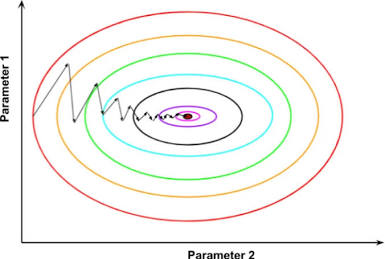

In [ ]:
file_path_pic_4 = '/content/drive/MyDrive/Hình project google colab/Gradient_Descent/4.png'
display(Image(filename=file_path_pic_4, width=600))

Chứng minh:

Giả sử ta có hàm nhiều biến $f(x, y)$. Một đường đồng mức của hàm số này được định nghĩa là tập hợp các điểm $(x, y)$ sao cho hàm số trên mọi điểm này đều có cùng một giá trị $c$. Tức là,

$$
f(x, y) = c
$$

Ta biểu diễn đường đồng mức này dưới dạng một đường cong tham số hóa theo biến $t$ **[1]**

Gọi $\mathbf{r}(t) = (x(t), y(t))$ là hàm vị trí của một điểm di chuyển dọc theo đường đồng mức. Vì điểm này luôn nằm trên đường đồng mức, nên nó thỏa mãn phương trình:

$$
f(x(t), y(t)) = c
$$

$$
\frac{d}{dt} f(x(t), y(t)) = \underbrace{\begin{bmatrix}\frac{\partial f}{\partial  x} & \frac{\partial f}{\partial y}\end{bmatrix}}_{\text{Vector Gradient}} \underbrace{\begin{bmatrix}\frac{\partial x}{\partial t} \\ \frac{\partial y}{\partial t}\end{bmatrix}}_{\text{Vector tiếp tuyến}}= \frac{d}{dt}(c) = 0
$$

Viết lại như sau,

$$
\nabla f^T \mathbf{r}'(t) = 0
$$

Từ biểu thức trên thì có thể thấy rõ như sau:

- $\mathbf{r}’(t)$ là vector tiếp tuyến của đường cong tại điểm $t$, $\nabla f$ là vector gradient của hàm $f$ tại điểm $t$.
- Vì tích vô hướng của chúng bằng $0$ nên ta có thể thấy là vector gradient $\nabla f$ luôn vuông góc với tiếp tuyến của đường đồng mức (đại diện cho hướng của đường đồng mức) tại mọi điểm.

Do vậy nhận xét trên là có cơ sở.


## (Stochastic) Gradient Descent cho NN
Thực tế cho thấy, trong nhiều bài toán machine learning, các điểm cực tiểu địa phương thường cho kết quả tốt, đặc biệt là trong các mạng neuron nhân tạo (sẽ chứng minh sau)

# Reference

https://machinelearningcoban.com/2017/01/12/gradientdescent/

https://machinelearningcoban.com/2017/01/16/gradientdescent2/

https://d2l.ai/

https://drive.google.com/file/d/1gY9UwYvWqh_QB90SmzVy3oYMn6EFIgCU/view?usp=sharing
